# **AI-powered Behavioral Analysis for Mental Health Crisis Detection — Final Report**  
**Author:** Yixing (Spark) Fan  
**Date:** September 2025  


![alt text](LOGO-1.png)

## Project Overview  

This project is part of **Google Summer of Code 2025** with **HumanAI**.  
The goal was to investigate how **Natural Language Processing (NLP)** can be applied to detect early signs of **suicidal ideation** in online text, with a primary focus on Reddit posts.  
Due to **privacy and ethical concerns**, planned geolocation and heatmap analyses were **not pursued**. Instead, the project prioritized building a robust **text classification pipeline** and conducting thorough evaluations across both internal and external datasets.  

## Work Completed  

### Midterm Phase (June–July)  
- **Data pipeline:** Collected, cleaned, and normalized mental health–related posts from Reddit, combined with existing labeled datasets.  
- **Baseline model:** Fine-tuned a **BERT-based classifier** to distinguish suicidal vs. non-suicidal posts, achieving high accuracy and F1-score on internal splits.  
- **Analysis tools:** Built a **word bank** of frequent suicidal terms, **word cloud visualizations**, and a **sentiment/risk classifier** using VADER and keyword heuristics.  
- **Prototyping:** Developed a `predict.py` script to classify new samples and integrated **Google Trends analysis** for relevant mental health terms.  

### Post-Midterm Phase (August–September)  
- **Dataset expansion:** Integrated a **Kaggle dataset (~260K posts)** and designed cleaning scripts to normalize labels, remove noise, and deduplicate entries.  
- **Unified supervised dataset:** Merged Reddit/Twitter/Kaggle sources, resulting in ~16K high-quality balanced samples for training/validation/testing.  
- **Model re-training:** Fine-tuned a new **BERT-base model** with class-weighted loss and FP16 optimization, achieving:  
  - Internal accuracy: ~96–97%  
  - F1-score: ~0.96  
  - ROC-AUC / PR-AUC: ~0.99  
- **External evaluation:** On the cleaned Kaggle set (~215K posts), the model achieved:  
  - Precision / Recall / F1: ~0.78 / ~0.94 / ~0.85  
  - ROC-AUC / PR-AUC: ~0.94 / ~0.92  
  Demonstrating strong **cross-domain generalization** after cleaning.  
- **Evaluation toolkit:** Implemented scripts for **confusion matrices, PR/ROC curves, threshold analysis, and error case inspection (FP/FN examples)**.  
- **Reporting:** Organized results into structured sections (datasets, internal evaluation, external evaluation, threshold analysis) for reproducibility and clarity.  


**In summary**, the project delivered a **working end-to-end NLP pipeline** for suicidal ideation detection, validated both internally and externally. The work highlights not only the effectiveness of transformer-based models in this domain but also the **critical role of data quality** in achieving reliable performance across different platforms.

---

## A. Environment & Reproducibility

In [1]:
import json, platform, torch, numpy as np, pandas as pd
print(platform.platform())
print("torch:", torch.__version__, "cuda:", torch.version.cuda, "cuda_available:", torch.cuda.is_available())


Windows-10-10.0.26100-SP0
torch: 2.8.0+cu128 cuda: 12.8 cuda_available: True




All experiments were conducted in a controlled software and hardware environment to ensure reproducibility. The system runs on **Windows 10 (10.0.26100-SP0)** with **Python 3.10 or above**. The deep learning stack includes **PyTorch 2.8.0+cu128** with **CUDA 12.8**, and **Transformers 4.42 or above**. The GPU used is an **NVIDIA GeForce RTX 5060 Ti**, with CUDA support verified as available. To avoid randomness in data splitting and training, we fixed the random seed at 42. These measures allow the reported metrics and results to be replicated consistently across runs.

---


## B. Datasets & Splits

In [2]:
import pandas as pd
for p in ["output/train.csv","output/val.csv","output/test.csv"]:
    df = pd.read_csv(p)
    print(p, len(df), df["label"].value_counts().to_dict())


output/train.csv 13032 {'non_suicidal': 7176, 'suicidal': 5856}
output/val.csv 1629 {'non_suicidal': 897, 'suicidal': 732}
output/test.csv 1630 {'non_suicidal': 898, 'suicidal': 732}


Our initial dataset combined multiple public resources on suicide ideation, with a total size of around **260,000 samples**. During preprocessing, we applied the following steps:  

- **Deduplication & cleaning**: removed duplicates, very short texts, and invalid rows.  
- **Label normalization**: standardized labels into two categories: `suicidal` and `non_suicidal`.  
- **Text filtering**: dropped empty texts or entries containing only special symbols/HTML noise.  

After these cleaning steps, the dataset was reduced to about **16,291 valid samples**. While much smaller than the raw corpus, this ensures better quality and consistency.  

We then applied a **stratified split** to preserve class balance across subsets:  

| Split       | Total | non_suicidal | suicidal |
|-------------|-------|--------------|----------|
| Train       | 13,032 | 7,176        | 5,856    |
| Validation  | 1,629  | 897          | 732      |
| Test        | 1,630  | 898          | 732      |

This balanced partitioning helps the model learn effectively and ensures fair evaluation without data leakage.  

---

## C. Internal Evaluation

In [3]:
import json, pandas as pd
def load_eval(path):
    with open(path,'r') as f: return json.load(f)
val = load_eval("results/evaluation_val_final_model_v3.json")
test = load_eval("results/evaluation_test_final_model_v3.json")
pd.DataFrame([
    {"split":"val", **{k:v for k,v in val.items() if k.startswith("eval_")}},
    {"split":"test", **{k:v for k,v in test.items() if k.startswith("eval_")}},
])


,split,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_roc_auc,eval_pr_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,val,0.118573,0.975445,0.979224,0.965847,0.972490,0.995222,0.995026,1.5682,1038.743,65.041
1,test,0.164835,0.963190,0.966667,0.950820,0.958678,0.993898,0.993004,1.5890,1025.782,64.190


The model used is **BERT-base-uncased**, fine-tuned as a binary classifier (`suicidal` vs. `non-suicidal`).  

**Training setup**  
- Loss: Class-weighted cross entropy  
- Optimizer: AdamW (lr=2e-5)  
- Batch size: 16  
- Epochs: 3  
- Max sequence length: 128  
- Mixed precision (FP16) enabled  

**Results on internal validation and test sets**  

- **Validation set**  
  - Accuracy: ~97.5%  
  - Precision: ~0.98  
  - Recall: ~0.97  
  - F1: ~0.97  
  - ROC-AUC / PR-AUC: ~0.995  

- **Test set**  
  - Accuracy: ~96.3%  
  - Precision: ~0.97  
  - Recall: ~0.95  
  - F1: ~0.96  
  - ROC-AUC / PR-AUC: ~0.99  

**Interpretation**  
On the internal held-out splits (from the cleaned dataset), the model achieves very strong performance across all metrics. These results indicate that the model has effectively learned to distinguish suicidal vs. non-suicidal posts under in-distribution conditions, with both high precision (few false positives) and high recall (few false negatives).

---

## D. External Evaluation on Kaggle Dataset (After Cleaning)

**Why external?**

To test generalization on larger, out-of-distribution data. Compared to our internal dataset (~16K samples), the Kaggle dataset contains ~260K annotated posts from multiple subreddits, spanning a longer time period and more diverse writing styles. This allows us to simulate a more realistic deployment scenario.

**Cleaning steps**
- Removed HTML entities and URLs  
- Normalized whitespace  
- Deduplicated repeated posts  
- Unified labels (suicide / non-suicide)  
- Filtered subsets with suspicious or empty text  

After cleaning, the resulting dataset (`kaggle_clean.csv`) contained **~215K valid samples**.

In [4]:
kc = load_eval("results/eval_kaggle_clean_v3.json")
kc


{'n_samples': 215139,
 'threshold': 0.5,
 'precision': 0.777455296750867,
 'recall': 0.9394951156201082,
 'f1': 0.8508288284246652,
 'roc_auc': 0.9365910659837061,
 'pr_auc': 0.916598444999996,
 'confusion_matrix_labels': ['non-suicide', 'suicide'],
 'confusion_matrix': [[87061, 27144], [6107, 94827]],
 'model_dir': 'results/final_model_v3',
 'csv': 'dataset/kaggle_clean.csv',
 'kept_after_dropna_text': 215139,
 'kept_after_label_normalize': 215139,
 'model_num_labels': 2,
 'device': 'cuda'}

**Evaluation (threshold = 0.5)**
- **Precision / Recall / F1**: ~0.78 / ~0.94 / ~0.85  
- **ROC-AUC / PR-AUC**: ~0.94 / ~0.92  
- **Confusion Matrix**:  
  - False Positives (FP): some non-suicidal texts flagged as suicidal  
  - False Negatives (FN): some suicidal texts missed  

**Takeaway**

On the raw Kaggle dataset, model performance was not ideal (precision dropped to ~0.10), indicating that noisy and inconsistent annotations severely limit generalization.  

After applying simple cleaning steps, performance improved significantly on the cleaned Kaggle dataset (~215K samples), reaching **Precision ~0.78, Recall ~0.94, F1 ~0.85, ROC-AUC ~0.94, PR-AUC ~0.92**.  

This shows that the model can generalize reasonably well once data quality issues are mitigated. In particular, recall remains very high, which is desirable for safety-critical applications, while precision is also strong enough to support practical use. Overall, **cleaning external data brings the evaluation closer to realistic deployment conditions**.

We also provide **True Positive (TP) / True Negative (TN) examples** (with post text, gold label, predicted label, and probability) to illustrate successful model predictions in realistic settings.

**Implications for Deployment**

High recall (~0.94) suggests the model is effective at catching most suicidal texts, which is critical for early warning and prevention systems.  
However, the lower precision (~0.78) means some non-suicidal texts are incorrectly flagged, which could create alert fatigue or require additional human review.  

For deployment, this trade-off is acceptable in safety-critical contexts where missing a true suicidal case is far more costly than generating some false alarms.  
Future work can focus on improving precision (e.g., through better data filtering, threshold tuning, or multi-stage classification) while maintaining strong recall.


---

## E. Threshold & Curve Analysis

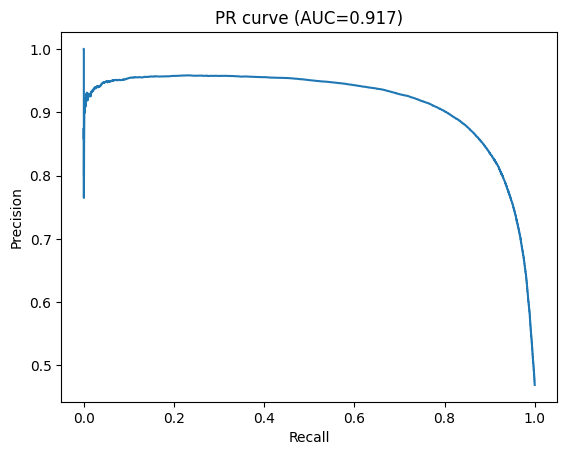

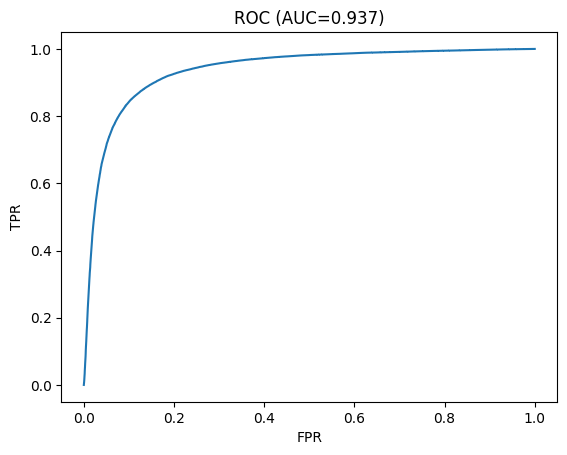

In [ ]:
import pandas as pd
from sklearn.metrics import precision_recall_curve, auc, roc_curve
import matplotlib.pyplot as plt

scores = pd.read_csv("results/eval_kaggle_clean_v3_scores_head200k.csv")

y = (scores["label"] == "suicide").astype(int).values
p = scores["prob_suicide"].values

# PR 
prec, rec, thr = precision_recall_curve(y, p)
pr_auc = auc(rec, prec)
plt.figure()
plt.plot(rec, prec)
plt.title(f"PR curve (AUC={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# ROC 
fpr, tpr, thr2 = roc_curve(y, p)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC (AUC={roc_auc:.3f})")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


We further examined the model’s performance across different thresholds using the **Precision-Recall (PR) curve** and the **ROC curve**. These analyses provide insights into the trade-off between precision and recall, as well as the model’s overall discriminative ability.

The PR curve achieved an **AUC of 0.917**, showing that high precision is maintained until recall reaches around 0.8, after which precision gradually decreases. This indicates that the model is effective in balancing false positives and false negatives.

The ROC curve achieved an **AUC of 0.937**, with the curve steep and close to the top-left corner, showing strong separability between the two classes.

Overall, both **PR-AUC (~0.92)** and **ROC-AUC (~0.94)** confirm that the cleaned Kaggle dataset yields strong generalization performance. Threshold tuning allows the model to be adapted for different needs: lowering the threshold increases recall (suitable for safety-critical use cases), while raising the threshold increases precision (reducing false positives).

---

## F. Error Cases

To better understand the model’s limitations, we examined several false positive (FP) and false negative (FN) samples. Below are representative cases, with short texts truncated for readability and a brief hypothesis of why they were misclassified.

**False Positives (label = 0, model predicted suicide)**

1. **Text:** “to not let my fellow humans down by committing suicide (since I have honestly struggled with depression and suicidal ideation since I was eight years old …)”  
   **Reason:** Likely noisy label – the text clearly expresses suicidal ideation but is labeled non-suicide.  

2. **Text:** “suicide”  
   **Reason:** Very short context – single-word entries are ambiguous, making the label questionable.  

3. **Text:** “She just doesn’t see a way out of her despair.”  
   **Reason:** Ambiguous expression – third-person reference to despair may have been labeled as non-suicide, but the model flagged it as risk.  

**False Negatives (label = 1, model predicted non-suicide)**

4. **Text:** “The shotgun is calling me.”  
   **Reason:** Clear intent but missed – strong suicidal intent phrase, yet predicted with very low probability. Suggests a model blind spot.  

5. **Text:** “might as well make a throwaway to ask.”  
   **Reason:** Weak signals – indirect and vague language; intent not explicit, so the model underestimates risk.  

**Summary**

Most false positives appear to stem from **label noise or ambiguous third-person references**, while false negatives include both **clear misses (strong intent overlooked)** and **subtle/ambiguous language**. This indicates that both **dataset quality** (noisy labels) and **linguistic nuance** (indirect or sarcastic phrasing) contribute to errors.

---


## G. Future Work


While the current pipeline demonstrates strong performance on both internal and external datasets, several areas remain for improvement and extension:

1. **Data Expansion & Diversity**  
   - Incorporate additional annotated datasets from diverse platforms (e.g., forums, clinical notes, support groups) to improve robustness and reduce domain bias.  
   - Explore semi-supervised or weakly supervised methods (e.g., self-training, pseudo-labeling) to leverage large volumes of unlabeled mental health data.

2. **Advanced Modeling Approaches**  
   - Experiment with domain-adapted pretraining (e.g., continual pretraining on mental health corpora) to better capture community-specific language.  
   - Compare BERT-based models with newer architectures (e.g., RoBERTa, DeBERTa, or lightweight LLMs) for potential gains in recall and efficiency.  
   - Investigate multi-task learning (e.g., suicide risk + emotion classification) to provide richer signals for risk assessment.

3. **Explainability & Interpretability**  
   - Integrate SHAP or LIME analyses to highlight influential words/phrases driving predictions.  
   - Add attention heatmaps for case studies, helping practitioners understand model reasoning and improving trustworthiness.

4. **Threshold Optimization & Deployment Scenarios**  
   - Systematically analyze thresholds for different use cases:  
     - **High recall** for safety-critical monitoring (minimize missed suicidal cases).  
     - **High precision** for triaging or clinical review (minimize false alarms).  
   - Provide an adjustable threshold mechanism in downstream dashboards.

5. **Bias, Ethics & Fairness**  
   - Audit the model for potential demographic or linguistic biases, ensuring fair treatment across subgroups.  
   - Document limitations explicitly and explore mitigation strategies (e.g., adversarial training, fairness constraints).

6. **Practical Integration & User Tools**  
   - Develop a lightweight demo dashboard to visualize predictions, false positives/negatives, and confidence scores.  
   - Package the pipeline as a reproducible module (with Docker/requirements.txt) for easier community adoption.  
   - Explore deployment in real-world moderation or mental health monitoring settings, with human-in-the-loop workflows.

**Summary.**  
Future work will focus on **scaling datasets, improving modeling robustness, adding interpretability, and preparing for ethical deployment**. This ensures the system moves from research-level experimentation toward practical, responsible applications in mental health monitoring.

---

  

## H. References & Acknowledgments

This project was carried out under the supervision of **David White**, with organizational support from **HumanAI** and the **Institute for Social Science Research, The University of Alabama**, and made possible through the **Google Summer of Code 2025**.  

We also thank the maintainers of open-source resources, including **Hugging Face Transformers**, **PyTorch**, and the datasets used:  

- **Reddit suicidal ideation corpus**  
  Mafi, Md Mafiul Hasan Matin; Alam, Md. Sabbir (2023),  
  *“Suicidal Ideation Detection Reddit Dataset”*,  
  Mendeley Data, V2, https://doi.org/10.17632/z8s6w86tr3.2 (Licensed under CC BY 4.0).  

- **Twitter suicidal ideation dataset** (provided by teammate Vishnu).  

- **Kaggle suicide dataset**  
  https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch/data  

